# This notebook is a demonstration of running the combined peak ranging and peak ion identification ML models

Ryan Jacobs, based on original code from Jingrui Wei

Last updated: 11/18/25 by Ryan Jacobs


# Install and setup for Google Colab

In [1]:
# Link Google drive

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
# Clone repo

!git clone https://github.com/uw-cmg/peak_detection

Cloning into 'peak_detection'...
remote: Enumerating objects: 20733, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 20733 (delta 26), reused 14 (delta 6), pack-reused 20675 (from 4)
Receiving objects: 100% (20733/20733), 117.76 MiB | 22.55 MiB/s, done.
Resolving deltas: 100% (378/378), done.
Updating files: 100% (20083/20083), done.


In [3]:
# Install dependencies. Now only takes < 1 min

!uv pip install -r "peak_detection/requirements.txt"

Using Python 3.12.12 environment at: /usr
Resolved 79 packages in 1.44s
Prepared 18 packages in 33.62s
Installed 18 packages in 164ms
 + apav==1.4.0
 + asteval==1.0.7
 + bibtexparser==1.4.3
 + colorama==0.4.6
 + fast-histogram==0.14
 + lmfit==1.3.4
 + monty==2025.3.3
 + palettable==3.3.3
 + periodictable==2.0.2
 + pymatgen==2025.10.7
 + pyqt5==5.15.11
 + pyqt5-qt5==5.15.18
 + pyqt5-sip==12.17.1
 + pyqtgraph==0.14.0
 + ruamel-yaml==0.18.16
 + ruamel-yaml-clib==0.2.15
 + spglib==2.6.0
 + uncertainties==3.2.3


In [4]:
# For Colab, move repo directories so imports work

import shutil
shutil.move('peak_detection', 'peak_detection_repo')
shutil.move('peak_detection_repo/peak_detection', '.')

'./peak_detection'

# Import needed packages

In [5]:
import apav
import os
import re
import pandas as pd
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
import torch.nn.functional as F
from scipy.signal import find_peaks
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import yaml
from pathlib import Path
import joblib
from pymatgen.core import Composition
import pandas as pd
import glob
import subprocess
import itertools

import peak_detection
from peak_detection.RangingNN.predictor import DetectionPredictor
from peak_detection.RangingNN.metrics import box_iou
from peak_detection.RangingNN.model_utils import cw2lh




/usr/local/lib/python3.12/dist-packages/apav/core/range.py:332: SyntaxWarning: invalid escape sequence '\*'
  Build RangeCollection from \*.rrng files
/content/peak_detection/RangingNN/predictor.py:205: SyntaxWarning: invalid escape sequence '\ '
  LOGGER.info(f"Results saved to {self.save_dir} \ results_range_indexes.pt ")


# Function definitions to do model predictions and visualization

In [27]:
def map01(ar):
    return (ar-ar.min()) / (ar.max()-ar.min())

def load_apt(apt_file):
    '''

    '''
    # Load the .apt file and get histogram
    d = apav.load_apt(apt_file)
    x, spectrum = d.mass_histogram(bin_width=0.01, lower=0, upper=307.2, multiplicity='all', norm=False,)
    spectrum_log = torch.tensor(map01(np.log(spectrum+1)), dtype=torch.float32)
    return spectrum, spectrum_log

def sort_predictions(peak_range_pred, elements):
    peak_range_pred_sort = peak_range_pred[peak_range_pred[:, 0].argsort()]
    inds = list(peak_range_pred[:, 0].argsort())
    inds = [int(i) for i in inds]
    elements_sort = [elements[i] for i in inds]
    return peak_range_pred_sort, elements_sort

def predict_peak_ranges(apt_file,
                        conf=0.05,
                        iou=0.01,
                        max_det=2000,
                        modelpath='/content/peak_detection/RangingNN/modelweights/best.pt',
                        from_custom_spectrum=False,
                        spectrum_log=None,
                        n_iter=1,
                        mc_min=None,
                        mc_max=None):
    '''
    HERE peak ranges
    '''

    if from_custom_spectrum == False:
        spectrum, spectrum_log = load_apt(apt_file=apt_file)

    # Load in the RangingNN model and do the peak detection
    #cfg = os.path.dirname(peak_detection.__file__) + '/RangingNN/cfg/prediction_args.yaml' # loading the default parameter file in the package
    cfg = 'peak_detection/RangingNN/cfg/prediction_args.yaml' # loading the default parameter file in the package
    cfg = yaml.safe_load(Path(cfg).read_text())

    cfg['iou'] = iou
    cfg['conf'] = conf
    cfg['max_det'] = max_det

    #modelpath = os.path.join(os.path.dirname(peak_detection.__file__), 'RangingNN/modelweights/best.pt') # loading the default trained-model in the package
    #print('spectrum log')
    #print(spectrum_log.shape)
    #print(spectrum_log)

    predictor = DetectionPredictor(modelpath, spectrum_log[None, None, ...], save_dir = 'test_results', cfg = cfg)
    result = predictor()[0]
    peak_range_pred = result[:,:2].cpu()
    counts = result[:,2].cpu()

    print('model predicted peaks:',peak_range_pred.shape[0])
    peak_range_toadd = list()
    counts_toadd = list()
    if n_iter > 0:
        for i in range(n_iter):
            print('On ranging model iteration', i)
            # Remove the old predicted peaks, run the model again, and keep any new found peaks
            idx_delete = list()
            multiplier = 0.01
            x1 = np.linspace(0.0, spectrum_log.shape[0]*0.01, spectrum_log.shape[0])
            print('Processing spectrum part 1')
            n = spectrum_log.shape[0]
            x1 = np.arange(n) * multiplier   # equivalent to your linspace
            # peak_range_pred: list of (start, end)
            ranges = np.asarray(peak_range_pred, dtype=float)   # shape (R, 2)
            starts = ranges[:, 0] * multiplier                  # shape (R,)
            ends   = ranges[:, 1] * multiplier                  # shape (R,)

            # Broadcasting: shape (n, R), then reduce along R
            in_any_range = np.logical_or.reduce(
                (x1[:, None] > starts[None, :]) &
                (x1[:, None] < ends[None, :]),
                axis=1
            )

            idx_delete = x1[in_any_range]
            #for i, j in zip(x1, spectrum_log):
            #    for start, end in peak_range_pred:
            #        if start*multiplier < i < end*multiplier:
            #            idx_delete.append(i)


            #print('idx delete shape', len(idx_delete))
            # Sub a constant 0.2 in for now
            #spectrum_log_mod = list()
            #for i, j in zip(x1, spectrum_log):
            #    if i in idx_delete:
            #        spectrum_log_mod.append(0.2)
            #    else:
            #        spectrum_log_mod.append(j)
            print('Processing spectrum part 2')
            x1 = np.asarray(x1)
            spectrum_log = np.asarray(spectrum_log)
            mask = np.isin(x1, idx_delete)

            spectrum_log_mod = spectrum_log.copy()
            spectrum_log_mod[mask] = 0.2

            spectrum_log_mod = torch.Tensor(spectrum_log_mod)
            print('Running predictions')
            predictor_mod = DetectionPredictor(modelpath, spectrum_log_mod[None, None, ...], save_dir = 'test_results', cfg = cfg)
            result_mod = predictor_mod()[0]
            peak_range_pred_mod = result_mod[:,:2].cpu()
            counts_mod = result_mod[:,2].cpu()
            print('peak range mod shape', peak_range_pred_mod.shape)
            #peak_range_pred_mod, counts_mod, result_mod = predict_peak_ranges(apt_file,
            #                                                                  conf=conf,
            #                                                                  iou=iou,
            #                                                                  max_det=max_det,
            #                                                                  modelpath=modelpath,
            #                                                                  from_custom_spectrum=True,
            #                                                                  spectrum_log=spectrum_log_mod,
            #                                                                  n_iter=1)

            # Collect any new peaks and append to the original list
            print('Processing newly detected peaks')
            tol = 0.5
            for i, count in zip(peak_range_pred_mod, counts_mod):
                start = float(i[0])
                end = float(i[1])
                max_iou = 1.0
                min_dist = 1000
                for j in peak_range_pred.tolist():

                    start2 = float(j[0])
                    end2 = float(j[1])
                    #print(abs(start-start2))
                    iou = calculate_iou_1d(interval1=[start, end], interval2=[start2, end2])
                    #ious.append(iou)
                    if iou < max_iou:
                        max_iou = iou

                        #start_found = start
                    if multiplier*abs(float(start)-float(start2)) < min_dist:
                        min_dist = multiplier*abs(float(start)-float(start2))
                    #print(start, start2, max_iou, min_dist)
                    #    # New peak found
                    #    print('HERE found new')
                    #    peak_range_toadd.append([start, end])
                    #    counts_toadd.append(count)
                # Want max iou to be 0 -> totally new peak
                #print('Max iou is', max_iou)
                if max_iou == 0.0:
                    if min_dist > tol:
                        if mc_min is not None and mc_max is not None:
                            if multiplier*start > mc_min and multiplier*end < mc_max:
                                print('Found new peak', multiplier*start, multiplier*end, 'with iou and dist', max_iou, min_dist)
                                peak_range_toadd.append([start, end])
                                counts_toadd.append(count)
                        else:
                            print('mc min/max set to None')
                            print('Found new peak', multiplier*start, multiplier*end, 'with iou and dist', max_iou, min_dist)
                            peak_range_toadd.append([start, end])
                            counts_toadd.append(count)

    peak_range_pred = peak_range_pred.tolist()
    counts = counts.tolist()

    for i, j in zip(peak_range_toadd, counts_toadd):
        peak_range_pred.append(i)
        counts.append(j)

    peak_range_pred = torch.Tensor(peak_range_pred)
    counts = torch.Tensor(counts)
    print('model predicted total peaks', peak_range_pred.shape, counts.shape)

    return peak_range_pred, counts, result

def plot_predictions(output_dir,
                     apt_file,
                     peak_range_pred,
                     res=None,
                     confidence=None,
                     plot_min=0,
                     plot_max=20000,
                     resort=True,
                     res2=None,
                     confidence2=None,
                     use_true_peaks=False):
    '''
    plot_max : # in 0.01 Da
    '''

    if use_true_peaks == True:
        multiplier = 0.001
        multiplier2 = 0.01
    else:
        multiplier = 0.01
        multiplier2 = 1.0

    colors = list(mcolors.TABLEAU_COLORS.values())
    color_inds = [int(np.random.uniform(0, len(colors))) for _ in range(peak_range_pred.shape[0])]

    plt.clf()
    plt.figure(figsize=(10, 6))
    spectrum, spectrum_log = load_apt(apt_file=apt_file)

    x = np.linspace(0.0, spectrum_log.shape[0]*0.01, spectrum_log.shape[0])
    plt.plot(x, spectrum_log)

    # Add color boxes for each peak range
    # Add vertical lines to show the boundaries of ranges

    peak_pred_ = peak_range_pred[(peak_range_pred[:,0]*multiplier2 < plot_max) & (peak_range_pred[:,0]*multiplier2 > plot_min)]

    count = 0
    for start, end in peak_pred_:
        plt.axvspan(start*multiplier, end*multiplier, alpha=0.3, color=colors[color_inds[count]])
        plt.axvline(start*multiplier, color=colors[color_inds[count]], linestyle='--', alpha=0.7, lw = 0.7)
        plt.axvline(end*multiplier, color=colors[color_inds[count]], linestyle='--', alpha=0.7, lw = 0.7)
        count += 1

    # Set labels and title
    plt.xlabel('Mass to charge ratio (Da)')
    plt.ylabel('Intensity in log scale normalized (counts)')

    plt.xlim(0.01*plot_min, 0.01*plot_max)

    if res is not None and confidence is not None:
        # Add the predicted ions and their confidences
        if resort == True:
            peak_range_pred = peak_range_pred[peak_range_pred[:, 0].argsort()][:, 0]
        else:
            peak_range_pred = peak_range_pred[:, 0]
        #for peak_start, ion, conf in zip(peak_range_pred[:,0], res, confidence):
        if res2 is not None:
            for peak_start, ion, conf, ion2, conf2 in zip(peak_range_pred, res, confidence, res2, confidence2):
                if peak_start*multiplier2 < plot_max and peak_start*multiplier2 > plot_min:
                    y_rand = np.random.uniform(low=0.5, high=1.0)
                    plt.text(multiplier*float(peak_start)+0.02, y_rand, ion+':'+str(round(conf,2)))
                    if conf2 > 0.0:
                        plt.text(multiplier*float(peak_start)+0.02, y_rand-0.05, ion2+':'+str(round(conf2,2)), color='blue')
                        #plt.text(0.01*float(peak_start)+0.02, 1.0, ion2+':'+str(round(conf2,2)), color='blue')
        else:
            for peak_start, ion, conf in zip(peak_range_pred, res, confidence):
                if peak_start*multiplier2 < plot_max and peak_start*multiplier2 > plot_min:
                    y_rand = np.random.uniform(low=0.5, high=1.0)
                    plt.text(multiplier*float(peak_start)+0.02, y_rand, ion+':'+str(round(conf,2)))
                    #plt.text(0.01*float(peak_start)+0.02, 1.05, ion+':'+str(round(conf,2)))

    # Adjust the plot layout
    plt.tight_layout()
    fname = apt_file.split('/')[-1]
    plt.savefig(os.path.join(output_dir, fname+'_ranging_ion_preds.png'), dpi=350, bbox_inches='tight')

    return

def calculate_iou_1d(interval1, interval2):
    """
    Calculates the Intersection over Union (IoU) of two 1D intervals.

    Args:
        interval1: A tuple or list of two numbers representing the start and end of the first interval.
        interval2: A tuple or list of two numbers representing the start and end of the second interval.

    Returns:
        The IoU of the two intervals, a float between 0 and 1.
    """

    start1, end1 = interval1
    start2, end2 = interval2

    intersection_start = max(start1, start2)
    intersection_end = min(end1, end2)

    intersection_length = max(0, intersection_end - intersection_start)

    union_length = (end1 - start1) + (end2 - start2) - intersection_length

    if union_length == 0:
        return 0.0

    iou = intersection_length / union_length
    return iou



# Here, use ranging model with iterative predictions

INFO:apav:Reading apt file: /content/drive/MyDrive/Cameca/Data_hdf5s/ALL_APT/R40_110290-v01 AuAlloy.apt


Start inference
Speed:  95.5ms inference, 7.4ms postprocess for per spectrum 
model predicted peaks: 58
On ranging model iteration 0
Processing spectrum part 1
Processing spectrum part 2
Running predictions
Start inference
Speed:  86.6ms inference, 2.3ms postprocess for per spectrum 


INFO:apav:Reading apt file: /content/drive/MyDrive/Cameca/Data_hdf5s/ALL_APT/R40_110290-v01 AuAlloy.apt


peak range mod shape torch.Size([18, 2])
Processing newly detected peaks
Found new peak 33.914814453125004 34.080986328125 with iou and dist 0.0 0.5487451171875
model predicted total peaks torch.Size([59, 2]) torch.Size([59])


<Figure size 640x480 with 0 Axes>

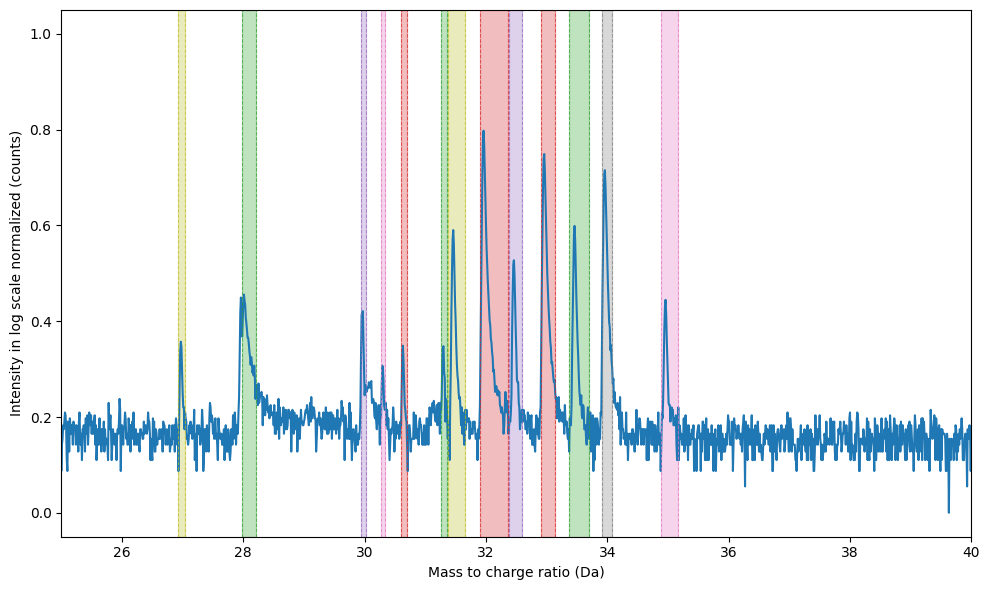

In [31]:
# Load in an .apt file and run both the ranging and ion classification models,
# then plot the results. This block uses in-development Random forest model

# Update the path to the .apt file you want to use the models on
#apt_file = '/content/drive/MyDrive/Cameca/R13_40310Zr Unsaved - Top Level ROI.apt'
apt_file = '/content/drive/MyDrive/Cameca/Data_hdf5s/ALL_APT/R40_110290-v01 AuAlloy.apt'

peak_range_pred, counts, result = predict_peak_ranges(apt_file,
                                                      conf=0.05,
                                                      iou=0.01,
                                                      max_det=2000,
                                                      modelpath='peak_detection/RangingNN/modelweights/best.pt', # best.pt, best_v0.pt, best_v0_2025-11-12.pt
                                                      n_iter=1,
                                                      mc_min=33,
                                                      mc_max=36)


plot_predictions(apt_file=apt_file,
                 peak_range_pred=peak_range_pred,
                 res=None,
                 confidence=None,
                 plot_min=2500,
                 plot_max=4000, #7100
                 resort=False,
                 res2=None,
                 confidence2=None,
                 output_dir=os.getcwd())

# Try idea of multiple rounds of peak ID to find more peaks

INFO:apav:Reading RRNG file: drive/MyDrive/Cameca/Data_hdf5s/ALL_RRNG/R40_110290Au.RRNG
INFO:apav:Reading apt file: drive/MyDrive/Cameca/Data_hdf5s/ALL_APT/R40_110290-v01 AuAlloy.apt
INFO:apav:Reading apt file: drive/MyDrive/Cameca/Data_hdf5s/ALL_APT/R40_110290-v01 AuAlloy.apt


spectrum log
torch.Size([30720])
tensor([0.5120, 0.4539, 0.4321,  ..., 0.1278, 0.1278, 0.1651])
Start inference
Speed:  82.0ms inference, 7.5ms postprocess for per spectrum 


INFO:apav:Reading apt file: drive/MyDrive/Cameca/Data_hdf5s/ALL_APT/R40_110290-v01 AuAlloy.apt


model predicted peaks: 58


(33.0, 35.0)

<Figure size 640x480 with 0 Axes>

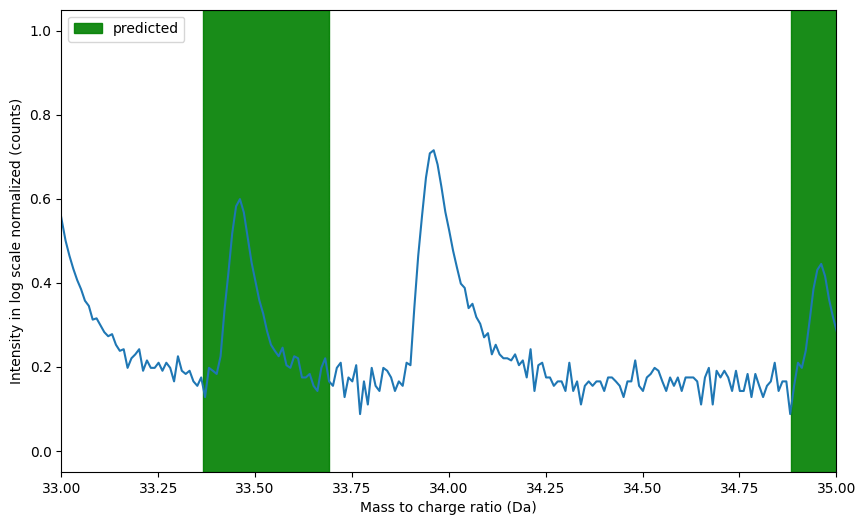

In [ ]:
rrng = 'drive/MyDrive/Cameca/Data_hdf5s/ALL_RRNG/R40_110290Au.RRNG'
apt_file = 'drive/MyDrive/Cameca/Data_hdf5s/ALL_APT/R40_110290-v01 AuAlloy.apt'

rng = apav.load_rrng(rrng)
d = apav.load_apt(apt_file)
x, spectrum = d.mass_histogram(bin_width=0.01, lower=0, upper=307.2, multiplicity='all', norm=False,)
spectrum_log = torch.tensor(map01(np.log(spectrum+1)), dtype=torch.float32)

lsts = list()
for i in rng:
    #all_trues.append(i.hill_formula)
    lsts.append(np.array([1000*i.lower, 1000*i.upper]))
true_ranges = np.array(lsts)

# Get peak ranges
peak_range_pred, counts, result = predict_peak_ranges(apt_file,
                                                      conf=0.05,
                                                      iou=0.01,
                                                      max_det=2000,
                                                      modelpath='peak_detection/RangingNN/modelweights/best.pt')
plot_min = 3300 #0
plot_max = 3500 #20000
multiplier = 0.01
multiplier2 = 1.0
multiplier3 = 0.001

#colors = list(mcolors.TABLEAU_COLORS.values())
#color_inds = [int(np.random.uniform(0, len(colors))) for _ in range(peak_range_pred.shape[0])]

plt.clf()
plt.figure(figsize=(10, 6))
spectrum, spectrum_log = load_apt(apt_file=apt_file)

x = np.linspace(0.0, spectrum_log.shape[0]*0.01, spectrum_log.shape[0])
plt.plot(x, spectrum_log)

# Add color boxes for each peak range
# Add vertical lines to show the boundaries of ranges

peak_pred_ = peak_range_pred[(peak_range_pred[:,0]*multiplier2 < plot_max) & (peak_range_pred[:,0]*multiplier2 > plot_min)]


count = 0
for start, end in peak_pred_:
    if count == 0:
        plt.axvspan(start*multiplier, end*multiplier, alpha=0.9, color='green', label='predicted')#colors[color_inds[count]])
    else:
        plt.axvspan(start*multiplier, end*multiplier, alpha=0.9, color='green')#colors[color_inds[count]])
    plt.axvline(start*multiplier, color='green', linestyle='--', alpha=0.1, lw = 0.7) #color=colors[color_inds[count]]
    plt.axvline(end*multiplier, color='green', linestyle='--', alpha=0.1, lw = 0.7)
    count += 1
#'''
# Add trues as well
count = 0
for start, end in true_ranges:
    if count == 0:
        plt.axvspan(start*multiplier3, end*multiplier3, alpha=0.3, color='blue', label='true')#colors[color_inds[count]])
    else:
        plt.axvspan(start*multiplier3, end*multiplier3, alpha=0.3, color='blue')#colors[color_inds[count]])
    plt.axvline(start*multiplier3, color='blue', linestyle='--', alpha=0, lw = 0.7) #color=colors[color_inds[count]]
    plt.axvline(end*multiplier3, color='blue', linestyle='--', alpha=0, lw = 0.7)
    count += 1
#'''

# Set labels and title
plt.xlabel('Mass to charge ratio (Da)')
plt.ylabel('Intensity in log scale normalized (counts)')
plt.legend(loc='best')

plt.xlim(0.01*plot_min, 0.01*plot_max)


In [ ]:
idx_delete = list()
for i, j in zip(x, spectrum_log):
    for start, end in peak_pred_:
        if start*multiplier < i < end*multiplier:
            idx_delete.append(i)

In [ ]:


# Sub a constant 0.2 in for now
spectrum_log_mod = list()
for i, j in zip(x, spectrum_log):
    if i in idx_delete:
        spectrum_log_mod.append(0.2)
    else:
        spectrum_log_mod.append(j)

spectrum_log_mod = torch.Tensor(spectrum_log_mod)
spectrum_log_mod

tensor([0.5120, 0.4539, 0.4321,  ..., 0.1278, 0.1278, 0.1651])

In [ ]:
spectrum_log_mod

tensor([0.5120, 0.4539, 0.4321,  ..., 0.1278, 0.1278, 0.1651])

spectrum log
torch.Size([30720])
tensor([0.5120, 0.4539, 0.4321,  ..., 0.1278, 0.1278, 0.1651])
Start inference
Speed:  85.9ms inference, 8.1ms postprocess for per spectrum 
model predicted peaks: 57


/tmp/ipython-input-983074431.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best')


(33.0, 35.0)

<Figure size 640x480 with 0 Axes>

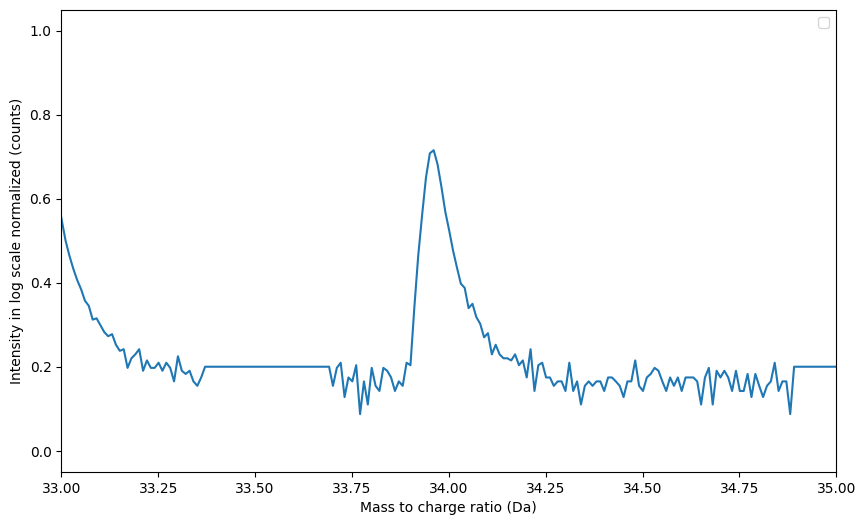

In [ ]:
# Now re-plot the data
plot_min = 3300 #0
plot_max = 3500 #20000
multiplier = 0.01
multiplier2 = 1.0
multiplier3 = 0.001

#colors = list(mcolors.TABLEAU_COLORS.values())
#color_inds = [int(np.random.uniform(0, len(colors))) for _ in range(peak_range_pred.shape[0])]

peak_range_pred_mod, counts, result = predict_peak_ranges(apt_file,
                                                      conf=0.05,
                                                      iou=0.01,
                                                      max_det=2000,
                                                      modelpath='peak_detection/RangingNN/modelweights/best.pt',
                                                      from_custom_spectrum=True,
                                                      spectrum_log=spectrum_log_mod)

plt.clf()
plt.figure(figsize=(10, 6))
#spectrum, spectrum_log = load_apt(apt_file=apt_file)

#x = np.linspace(0.0, spectrum_log.shape[0]*0.01, spectrum_log.shape[0])
plt.plot(x, spectrum_log_mod)

# Add color boxes for each peak range
# Add vertical lines to show the boundaries of ranges

peak_pred_mod = peak_range_pred_mod[(peak_range_pred_mod[:,0]*multiplier2 < plot_max) & (peak_range_pred_mod[:,0]*multiplier2 > plot_min)]

'''
count = 0
for start, end in peak_pred_mod:
    if count == 0:
        plt.axvspan(start*multiplier, end*multiplier, alpha=0.9, color='green', label='predicted')#colors[color_inds[count]])
    else:
        plt.axvspan(start*multiplier, end*multiplier, alpha=0.9, color='green')#colors[color_inds[count]])
    plt.axvline(start*multiplier, color='green', linestyle='--', alpha=0.1, lw = 0.7) #color=colors[color_inds[count]]
    plt.axvline(end*multiplier, color='green', linestyle='--', alpha=0.1, lw = 0.7)
    count += 1
'''
# Add trues as well
'''
count = 0
for start, end in true_ranges:
    if count == 0:
        plt.axvspan(start*multiplier3, end*multiplier3, alpha=0.3, color='blue', label='true')#colors[color_inds[count]])
    else:
        plt.axvspan(start*multiplier3, end*multiplier3, alpha=0.3, color='blue')#colors[color_inds[count]])
    plt.axvline(start*multiplier3, color='blue', linestyle='--', alpha=0, lw = 0.7) #color=colors[color_inds[count]]
    plt.axvline(end*multiplier3, color='blue', linestyle='--', alpha=0, lw = 0.7)
    count += 1
'''

# Set labels and title
plt.xlabel('Mass to charge ratio (Da)')
plt.ylabel('Intensity in log scale normalized (counts)')
plt.legend(loc='best')

plt.xlim(0.01*plot_min, 0.01*plot_max)

In [ ]:
peak_pred_

tensor([[3001.9927, 3018.9556],
        [2793.2568, 2802.6123],
        [1403.9102, 1410.2441],
        [1807.4354, 1813.7072],
        [3391.4814, 3408.0986]])

In [ ]:
idx_delete

[np.float64(11.980389986653211),
 np.float64(11.99039031218464),
 np.float64(12.000390637716071),
 np.float64(12.0103909632475),
 np.float64(12.480406263224713),
 np.float64(12.490406588756143),
 np.float64(12.500406914287574),
 np.float64(13.48043881636772),
 np.float64(13.490439141899149),
 np.float64(13.50043946743058),
 np.float64(13.510439792962009),
 np.float64(13.960454441876362),
 np.float64(13.970454767407793),
 np.float64(13.980455092939222),
 np.float64(13.990455418470653),
 np.float64(14.000455744002082),
 np.float64(14.010456069533513),
 np.float64(14.020456395064942),
 np.float64(14.030456720596373),
 np.float64(14.040457046127802),
 np.float64(14.050457371659233),
 np.float64(14.060457697190662),
 np.float64(14.470471043979295),
 np.float64(14.480471369510726),
 np.float64(14.490471695042155),
 np.float64(14.500472020573586),
 np.float64(14.510472346105015),
 np.float64(14.980487646082228),
 np.float64(14.990487971613659),
 np.float64(15.000488297145088),
 np.float64(15.